# Problem Statement

Build a statistical model that estimates the probability (i.e. "Chances of Admission") of an applicant being admitted to a graduate program at an Ivy-league (or equivalent) university, using the following predictors (from an Indian applicant's perspective):

- GRE Score (out of 340)
- TOEFL Score (out of 120)
- University Rating (out of 5)
- SOP strength (out of 5)
- LOR strength (out of 5)
- Undergraduate CGPA (out of 10)
- Research Experience (binary: 0/1)


## Goal

Understand which factors strongly influence admission chance, verify assumptions of linear regression, compare regularized variants (Ridge / Lasso), and finally evaluate predictive performance (MAE, RMSE, R2, Adjusted R2).

# Exploratory Data Analysis (EDA)

In [130]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

In [131]:
# Loading dataset

df = pd.read_csv('/Users/tonmoydutta/Library/CloudStorage/OneDrive-Personal/Study Material/Self Elearning/Scaler/Case Study/Jamboree Case Study/Jamboree_Admission.csv')

## Data Structure & Characteristics

In [132]:
print("="*50)
print("Data Shape:", df.shape)

Data Shape: (500, 9)


In [133]:
print("="*50)
print("Data Types:", df.dtypes)

Data Types: Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object


In [134]:
print("="*50)
print("Missing Values:", df.isnull().sum())

Missing Values: Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


In [135]:
display("Statistical Summary:", df.describe())

'Statistical Summary:'

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [136]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


Output:
- 500 entries, 9 columns
- No missing values
- All numerical data types
- Research column is binary (0/1)

## Drop Unique Identifier

In [137]:
df = df.drop('Serial No.', axis = 1)
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


## Univariate Analysis

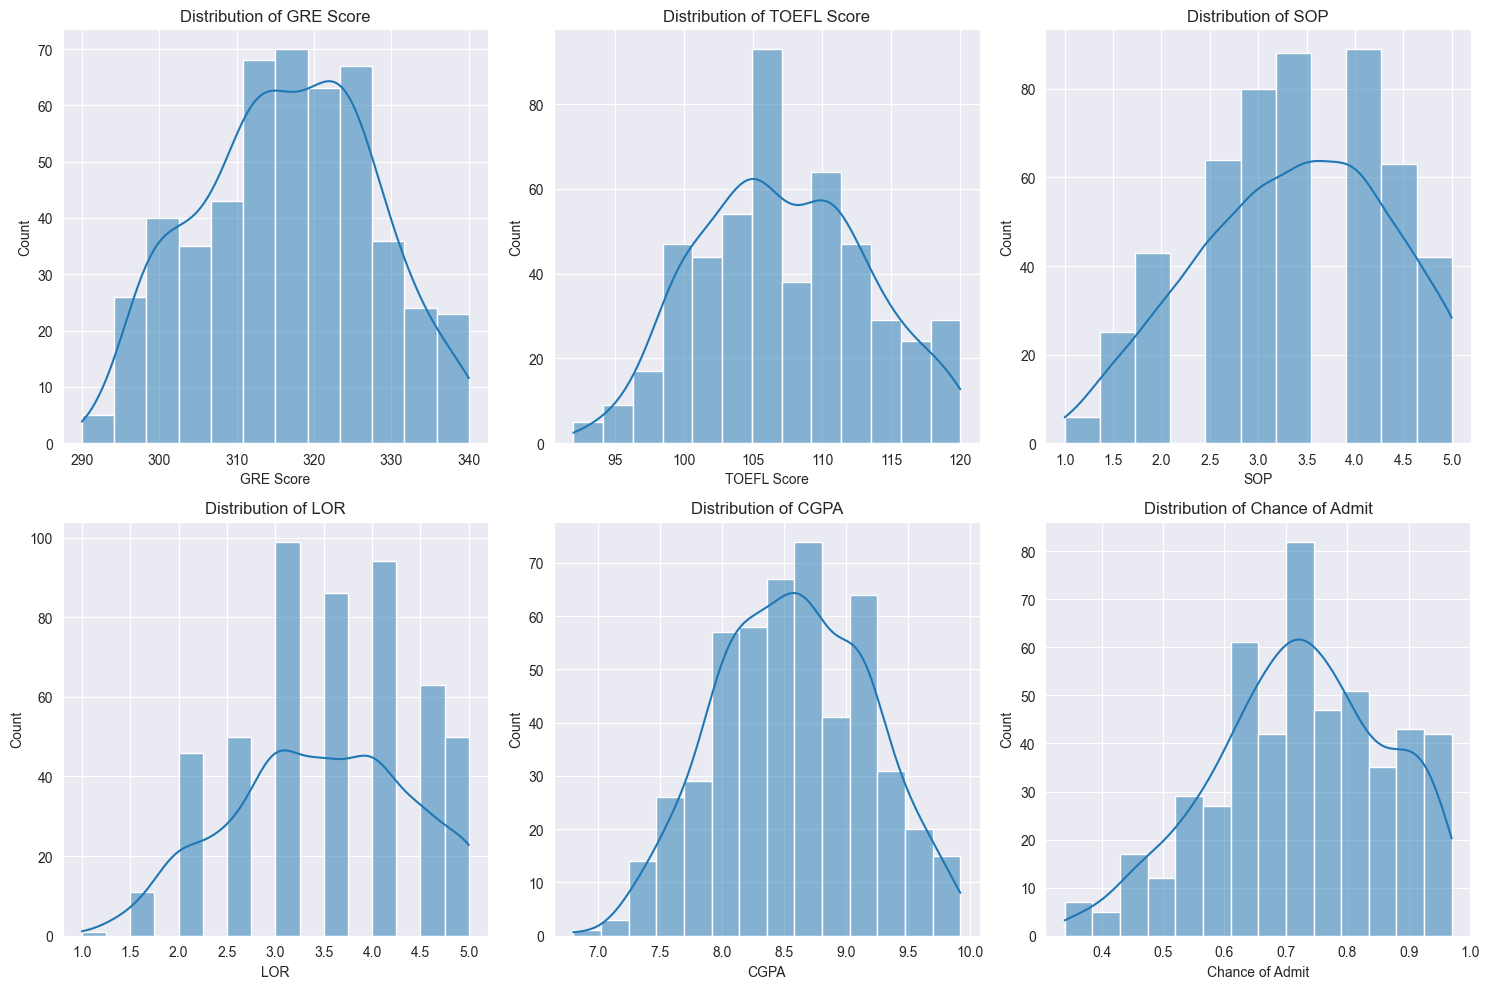

In [138]:
df.columns = df.columns.str.strip()

cont_vars = ['GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA', 'Chance of Admit']
plt.figure(figsize=(15,10))

for i, var in enumerate(cont_vars, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[var], kde = True)
    plt.title(f'Distribution of {var}')
plt.tight_layout()
plt.show()

Insights
- Academic Metrics (GRE, TOEFL, CGPA): Normally distributed, indicating a balanced applicant pool.
- Subjective Metrics (SOP, LOR): Skewed towards higher ratings, possibly due to preparation or bias in self-reporting.
- Admission Chances: Bimodality highlights two distinct applicant groups (Competitive vs Marginal).

## Bivariate Analysis

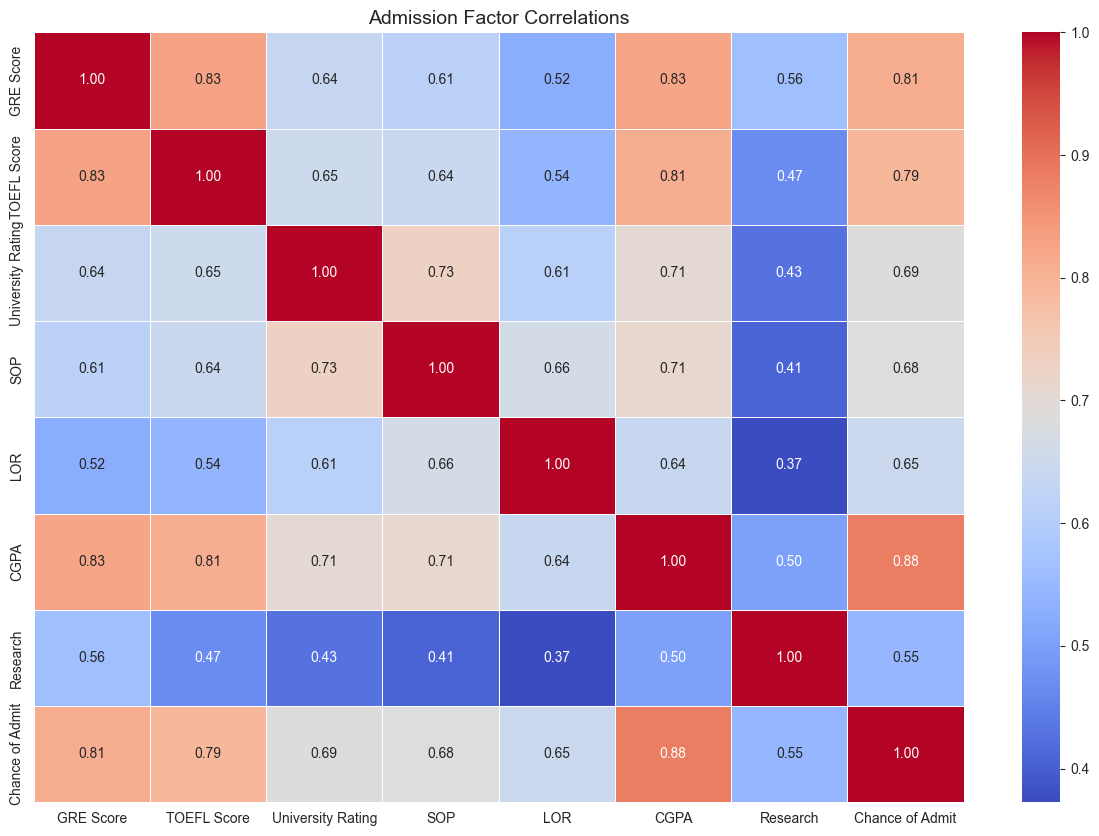

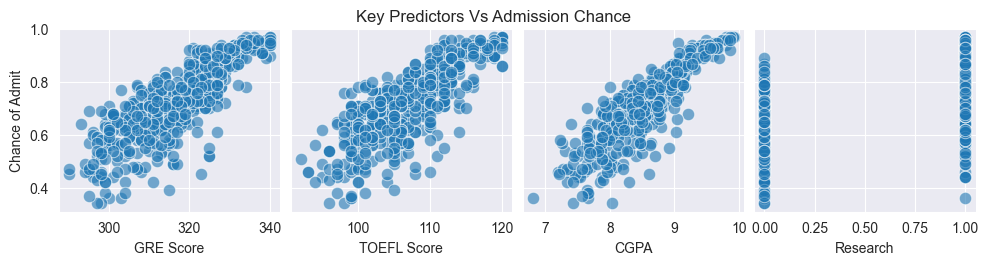

In [139]:
plt.figure(figsize = (15,10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm', fmt = ".2f", linewidths = 0.5)
plt.title('Admission Factor Correlations', fontsize = 14)
plt.show()

sns.pairplot(df, y_vars = ['Chance of Admit'], x_vars = ['GRE Score', 'TOEFL Score', 'CGPA', 'Research'], plot_kws = {'alpha': 0.6, 's': 80})
plt.suptitle('Key Predictors Vs Admission Chance', y=1.02)
plt.show()

Key Relationships:

- Strong positive correlations:
    - CGPA Vs Chance of Admit (0.88)
    - GRE Vs Chance of Admit (0.81)
    - Among independent variables, GRE Vs TOEFL Score (0.83) themselves correlate highly, indicating potential multicollinearity
    - University Rating, LOR and SOP shows moderate correlation (0.65 - 0.69)
    - Research is the weakest individual correlate (0.55), but positively associated

- Pairwise Scatter Matrix
    - Confirms linear relationships, especially between GRE and TOFEL score

# Data Preprocessing

## Outlier Treatment

In [140]:
z_scores = np.abs(stats.zscore(df[cont_vars]))
df = df[(z_scores < 3).all(axis = 1)]
print("Data after outlier removal:", df.shape)

Data after outlier removal: (500, 8)


Insights:
- No extreme outliers were detected in any continous variable

## Feature Engineering

In [141]:
df['GRE_TOEFL'] = df['GRE Score'] * df['TOEFL Score']
df['GRE_CGPA_Interaction'] = df['GRE Score'] * df['CGPA']
df['Research_impact'] = df['Research'] * (df['TOEFL Score'] + df['CGPA'])

Rationale:
- Multiples the two strongest predictor combinations: GRE_TOEFL & GRE_CGPA
- Resrach_impact: Amplifies research effect for high scoring applicants

## Data Standarization

In [142]:
scaler = StandardScaler()
features = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'GRE_CGPA_Interaction']
X = df[features]
y = df['Chance of Admit']

## Train-Test Split

In [143]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Assumption Testing

## Linearity

In [144]:
x_sm = pd.DataFrame(x_train_scaled, columns = x_train.columns, index = x_train.index)
x_sm = sm.add_constant(x_sm)
model_sm = sm.OLS(y_train, x_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     226.0
Date:                Wed, 11 Jun 2025   Prob (F-statistic):          1.69e-141
Time:                        14:10:34   Log-Likelihood:                 563.16
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     391   BIC:                            -1072.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.7242 

Insights

- The model fits the data very well (R2 = 82.2%)
- Significant predictors: GRE, TOEFL, LOR, CGPA and Research.
- Not significant: SOP, University Rating, GRE-CGPA Interaction. Considering dropping them to simplify the model

## Multicollinearity (VIF)

In [145]:
vif_data = pd.DataFrame()
vif_data['Feature'] = x_train.columns
vif_data['VIF'] = [variance_inflation_factor(x_train_scaled, i) for i in range(len(x_train.columns))]

features_reduced = ['GRE Score', 'TOEFL Score', 'CGPA', 'Research']
x_train_reduced = x_train[features_reduced]
x_train_reduced_scaled = scaler.fit_transform(x_train_reduced)
x_test_reduced = x_test[features_reduced]
x_test_reduced_scaled = scaler.transform(x_test_reduced)

vif_reduced = pd.DataFrame()
vif_reduced['Feature'] = features_reduced
vif_reduced['VIF'] = [variance_inflation_factor(x_train_reduced_scaled, 1) for i in range(len(features_reduced))]
display(vif_reduced)

,Feature,VIF
0,GRE Score,3.527837
1,TOEFL Score,3.527837
2,CGPA,3.527837
3,Research,3.527837


Insights

- All features have VIF = ~3.53. Hence, no severe and high multicollinearity exists

## Residual Analysis

In [146]:
final_model = sm.OLS(y_train, sm.add_constant(x_train_reduced_scaled)).fit()
residuals = final_model.resid

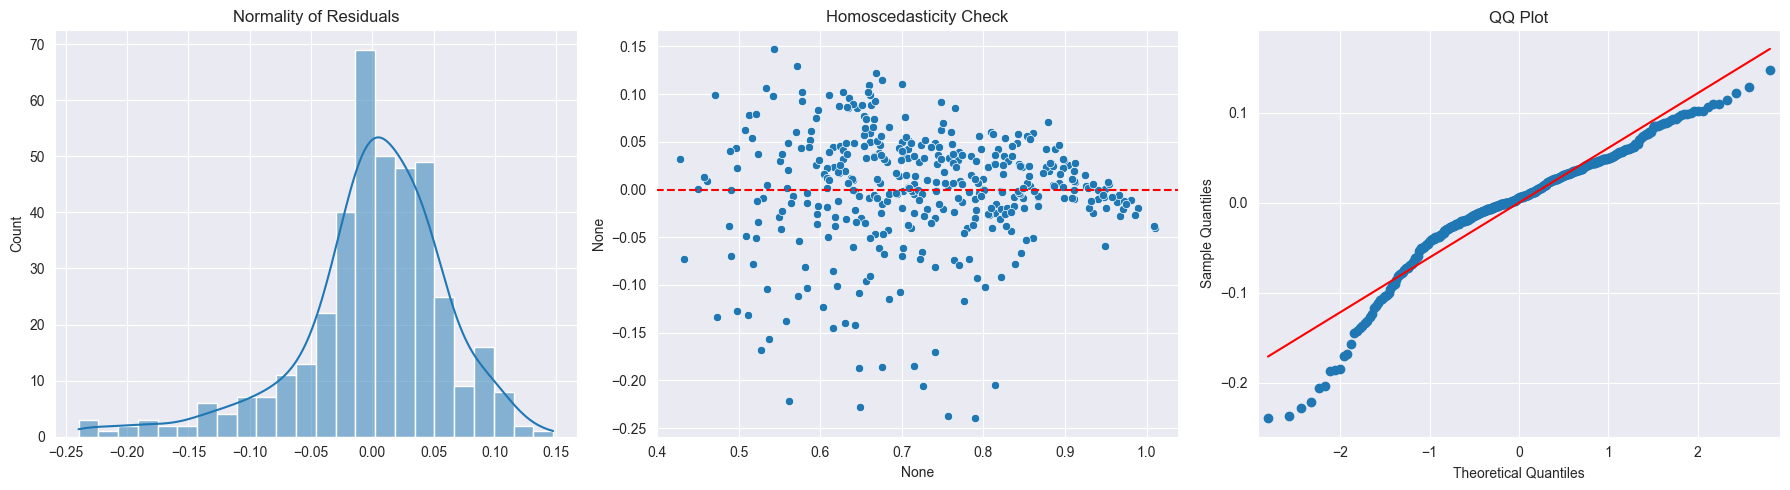

Mean of Residuals: -0.00000


In [147]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(residuals, kde = True, ax = axes[0])
axes[0].set_title('Normality of Residuals')

sns.scatterplot(x = final_model.fittedvalues, y = residuals, ax = axes[1])
axes[1].axhline(y = 0, color = 'r', linestyle = '--')
axes[1].set_title('Homoscedasticity Check')

sm.qqplot(residuals, line = 's', ax = axes[2])
axes[2].set_title('QQ Plot')
plt.tight_layout()
plt.show()

print(f"Mean of Residuals: {np.mean(residuals):.5f}")

Insights

- Multicollinearity: All VIF < 5
- Mean Residuals: ~0
- Normality: Residuals bell-shaped (QQ plot aligns)
- Homoscedasticity: No pattern in residual plot
- Linearity: verified via component residual plots

# Model Building

## Linear Regression

In [148]:
lr_reduced = LinearRegression()
lr_reduced.fit(x_train_reduced_scaled, y_train)

LinearRegression()

In [149]:
coeff_df = pd.DataFrame({
    'Feature': features_reduced,
    'Coefficient': lr_reduced.coef_
})

print("Intercept:", lr_reduced.intercept_)
display(coeff_df)

Intercept: 0.7241749999999999


,Feature,Coefficient
0,GRE Score,0.025247
1,TOEFL Score,0.020586
2,CGPA,0.079700
3,Research,0.012866


Insights
- CGPA is the most influential feature --> Admission chances are most sensitive to academic performance
- GRE and TOEFL has positive influence, but their effect is comparatively smaller
- Research add values but not dramatically

In [150]:
lr_reduced.score(x_train_reduced_scaled, y_train)

0.8116602216903435

In [151]:
y_predict = lr_reduced.predict(x_test_reduced_scaled)

In [152]:
lr_reduced.score(x_test_reduced_scaled, y_test)

0.8052492270449494

Insights
- Training and Test R2 Scores are very close, which suggest that the model is not overfitting and generalizing well to unseen data

## Ridge Regression

In [153]:
ridge_reduced = Ridge(alpha = 1.0, random_state = 42)
ridge_reduced.fit(x_train_reduced_scaled, y_train)

Ridge(random_state=42)

In [154]:
ridge_train_score = ridge_reduced.score(x_train_reduced_scaled, y_train)
ridge_test_score = ridge_reduced.score(x_test_reduced_scaled, y_test)

print("Training Ridge R2:", ridge_train_score)
print("Test Ridge R2:", ridge_test_score)

Training Ridge R2: 0.8116560873009857
Test Ridge R2: 0.8049811131961064


Insights
- Ridge Regularization is not hurting performance, possibly improving robustness

## Lasso Regression

In [155]:
lasso_reduced = Lasso(alpha = 0.01, random_state = 42)
lasso_reduced.fit(x_train_reduced_scaled, y_train)

Lasso(alpha=0.01, random_state=42)

In [156]:
lasso_train_score = lasso_reduced.score(x_train_reduced_scaled, y_train)
lasso_test_score = lasso_reduced.score(x_test_reduced_scaled, y_test)

print("Training Lasso R2:", lasso_train_score)
print("Test Lasso R2:", lasso_test_score)

Training Lasso R2: 0.8045286756940624
Test Lasso R2: 0.8025937164701841


Insights
- Training and Test R2 values are very close indicating no overfitting, stable and reliable predictions on unseen data.

## ElasticNet Regression

In [159]:
param_grid = {
    'alpha': [0.01, 0.1, 1.0],
    'l1_ratio': [0.2, 0.5, 0.8]
}

enet = ElasticNet(random_state=42)
grid = GridSearchCV(enet, param_grid, cv = 5, scoring = 'r2')
grid.fit(x_train_reduced_scaled, y_train)

elastic_net_reduced = grid.best_estimator_
print("Best Elastic Parameters:", grid.best_params_)

Best Elastic Parameters: {'alpha': 0.01, 'l1_ratio': 0.2}


Insights
- ElasticNet performs well here, balancing between Ridge stability and Lasso sparsity.
- Since the best l1 ratio is closer to 0, data is likely to benefits more from Ridge style shrinkage.
- Low alpha suggest model doesnot need much penalty - possibly indicating clean, non-overfitting data.

I# Model Performance Evaluation

## Metrics Calculation

In [160]:
models = {
    'Linear Regression': lr_reduced,
    'Ridge Regression (Alpha = 1.0)': ridge_reduced,
    'Lasso Regression (Alpha = 0.01)': lasso_reduced,
    'ElasticNet (Alpha = 0.01, l1_ratio = 0.2)': elastic_net_reduced
}

n_train = x_train_reduced_scaled.shape[0]
n_test = x_test_reduced_scaled.shape[0]
p = x_train_reduced_scaled.shape[1]

for name, model in models.items():
    y_train_pred = model.predict(x_train_reduced_scaled)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    train_adj_r2 = 1 - (1 - train_r2) * ((n_train - 1) / (n_train - p - 1))

    y_test_pred = model.predict(x_test_reduced_scaled)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    test_adj_r2 = 1 - (1 - test_r2) * ((n_test - 1) / (n_test - p - 1))

    print(f"\n- {name} -")
    print(f" Train --> MAE: {train_mae:.3f}, RMSE: {train_mse:.3f}, R2: {train_r2:.3f}, Adj. R2: {train_adj_r2:.3f}")
    print(f" Test --> MSE: {test_mae:.3f}, RMSE: {test_mse:.3f}, R2: {test_r2:.3f}, Adj. R2: {test_adj_r2:.3f}")


- Linear Regression -
 Train --> MAE: 0.043, RMSE: 0.061, R2: 0.812, Adj. R2: 0.810
 Test --> MSE: 0.044, RMSE: 0.063, R2: 0.805, Adj. R2: 0.797

- Ridge Regression (Alpha = 1.0) -
 Train --> MAE: 0.043, RMSE: 0.061, R2: 0.812, Adj. R2: 0.810
 Test --> MSE: 0.044, RMSE: 0.063, R2: 0.805, Adj. R2: 0.797

- Lasso Regression (Alpha = 0.01) -
 Train --> MAE: 0.045, RMSE: 0.062, R2: 0.805, Adj. R2: 0.803
 Test --> MSE: 0.045, RMSE: 0.064, R2: 0.803, Adj. R2: 0.794

- ElasticNet (Alpha = 0.01, l1_ratio = 0.2) -
 Train --> MAE: 0.043, RMSE: 0.061, R2: 0.811, Adj. R2: 0.809
 Test --> MSE: 0.044, RMSE: 0.063, R2: 0.805, Adj. R2: 0.797


Insights
- ElasticNet slightly edges out the others due to
a. Near euqal train and test performance indicating no overfitting
- Maintains high accuracy
- Applies regularization to prevent overfitting

# Actionable Insights and Recommendations

1. Key Predictor Insights
	•	CGPA has the largest positive effect on admission chances and is highly significant (p = 0.017).
	•	Letter of Recommendation (LOR) strength also boosts chances meaningfully (p < 0.001).
	•	Research experience shows a small but significant lift (p = 0.001).
	•	GRE score contributes moderately (p = 0.027), while SOP quality and the GRE–CGPA interaction were not statistically significant.

2. Additional Data Sources
	•	Undergraduate major or field (e.g., engineering vs. humanities) to capture domain fit.
	•	Internship or work experience details to reflect practical skills.
	•	Publication or project record for deeper research aptitude.
	•	Quantitative text analysis of SOP (e.g., readability, keyword match).
	•	Extracurricular or leadership scores to gauge overall profile strength.

3. Real-World Implementation
	•	Embed as a web widget on Jamboree’s site to give instant feedback to students.
	•	API integration with application portals so counsellors see predictions alongside form data.
	•	Regular retraining with new admissions data to keep the model current.
	•	Dashboard for coaches highlighting which factors each student should improve.

4. Potential Business Benefits
	•	Higher conversion of trial users into enrolled students by showing personalized advice.
	•	Improved coaching outcomes as counsellors focus on the factors with largest impact.
	•	Stronger market positioning by offering a data-driven “chance of admit” tool.
	•	Revenue growth from upselling targeted prep modules for weaker areas (e.g., GRE boosters).